## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle
import os

sns.set_theme(style="whitegrid")
os.makedirs("../reports/model_plots", exist_ok=True)
os.makedirs("../models", exist_ok=True)

## Load Model ready data

In [2]:
df = pd.read_csv("../data/processed/model_ready.csv")

print("Shape:", df.shape)
print("Target column: log_salary")
print("Feature columns:", df.shape[1] - 1)

Shape: (1500, 55)
Target column: log_salary
Feature columns: 54


## Split Features and target

In [3]:
X = df.drop(columns=["log_salary"])
y = df["log_salary"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y mean:", y.mean().round(4))
print("y std:", y.std().round(4))

X shape: (1500, 54)
y shape: (1500,)
y mean: 12.124
y std: 0.3348


## Train-test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train samples:", X_train.shape[0])
print("Test samples: ", X_test.shape[0])

Train samples: 1200
Test samples:  300


## Train the model

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")
print("Intercept:", round(model.intercept_, 4))
print("Number of coefficients:", len(model.coef_))

Model trained.
Intercept: 12.1963
Number of coefficients: 54


## Predictions

In [6]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Convert back to dollars for interpretable evaluation
y_test_dollars  = np.exp(y_test)
y_pred_dollars  = np.exp(y_pred_test)

## Core Metrices

In [7]:
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)
mae      = mean_absolute_error(y_test, y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_usd  = mean_absolute_error(y_test_dollars, y_pred_dollars)
rmse_usd = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

print(f"Train R²     : {r2_train:.4f}")
print(f"Test R²      : {r2_test:.4f}")
print(f"MAE  (log)   : {mae:.4f}")
print(f"RMSE (log)   : {rmse:.4f}")
print(f"MAE  (USD)   : ${mae_usd:,.0f}")
print(f"RMSE (USD)   : ${rmse_usd:,.0f}")

Train R²     : 0.8701
Test R²      : 0.8395
MAE  (log)   : 0.1003
RMSE (log)   : 0.1321
MAE  (USD)   : $18,824
RMSE (USD)   : $24,991


## 5-fold cross validation

In [8]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean R² : {cv_scores.mean():.4f}")
print(f"Std     : {cv_scores.std():.4f}")

Fold 1: 0.8573
Fold 2: 0.8670
Fold 3: 0.8738
Fold 4: 0.8551
Fold 5: 0.8037

Mean R² : 0.8514
Std     : 0.0248


## Actual vs Predicted plot

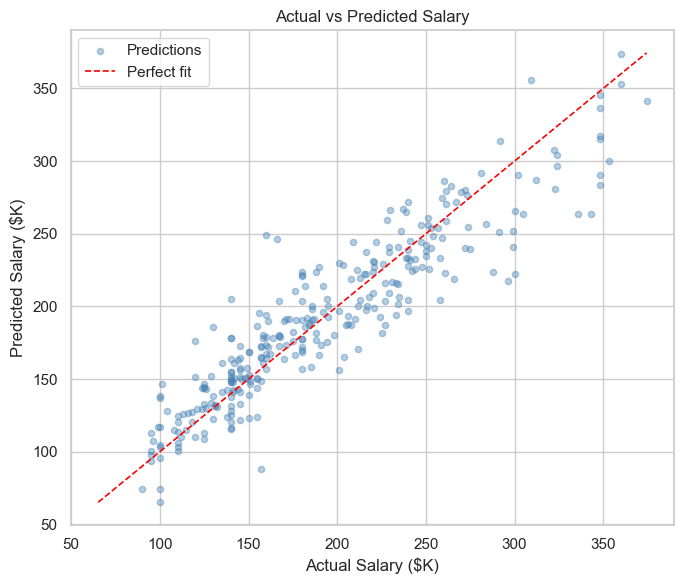

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_dollars / 1000, y_pred_dollars / 1000,
            alpha=0.4, color="steelblue", s=20, label="Predictions")
min_val = min(y_test_dollars.min(), y_pred_dollars.min()) / 1000
max_val = max(y_test_dollars.max(), y_pred_dollars.max()) / 1000
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linewidth=1.2, linestyle="--", label="Perfect fit")
plt.xlabel("Actual Salary ($K)")
plt.ylabel("Predicted Salary ($K)")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/model_plots/actual_vs_predicted.png", dpi=150)
plt.show()

## Residuals vs Predicted

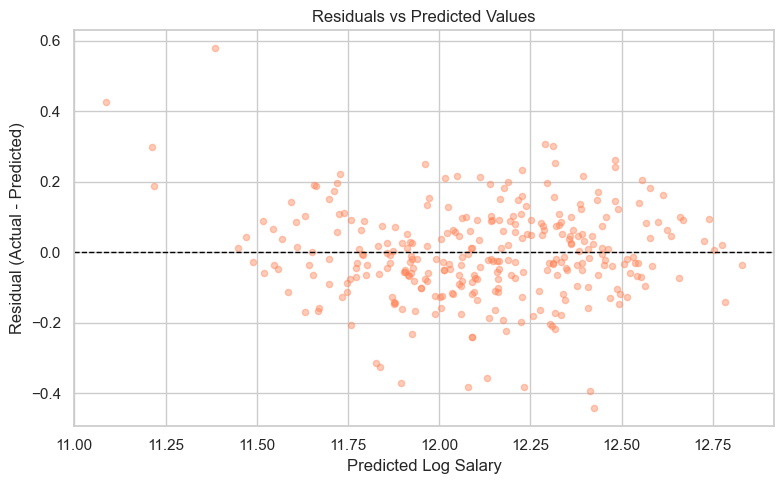

Residual mean : -0.0058
Residual std  : 0.1322
Residual min  : -0.4419
Residual max  : 0.5789


In [10]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test, residuals, alpha=0.4, color="coral", s=20)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("Predicted Log Salary")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.savefig("../reports/model_plots/residuals_vs_predicted.png", dpi=150)
plt.show()

print(f"Residual mean : {residuals.mean():.4f}")
print(f"Residual std  : {residuals.std():.4f}")
print(f"Residual min  : {residuals.min():.4f}")
print(f"Residual max  : {residuals.max():.4f}")

## Residual Distribution

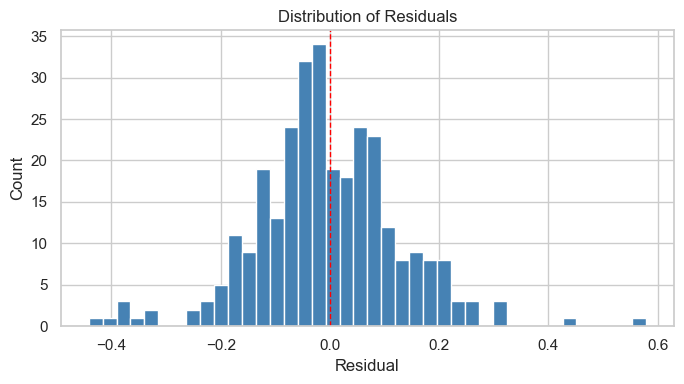

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.savefig("../reports/model_plots/residual_distribution.png", dpi=150)
plt.show()

## Prediction error distribution in dollars

In [12]:
errors_dollars = y_test_dollars - y_pred_dollars
thresholds = [10_000, 20_000, 30_000, 50_000]

print("Prediction accuracy in dollar terms (test set = 300 samples):\n")
for t in thresholds:
    count = (np.abs(errors_dollars) <= t).sum()
    pct = count / len(errors_dollars) * 100
    print(f"Within ${t:,}  :  {count}/300  ({pct:.1f}%)")

Prediction accuracy in dollar terms (test set = 300 samples):

Within $10,000  :  109/300  (36.3%)
Within $20,000  :  200/300  (66.7%)
Within $30,000  :  237/300  (79.0%)
Within $50,000  :  284/300  (94.7%)


## Top Feature coefficients

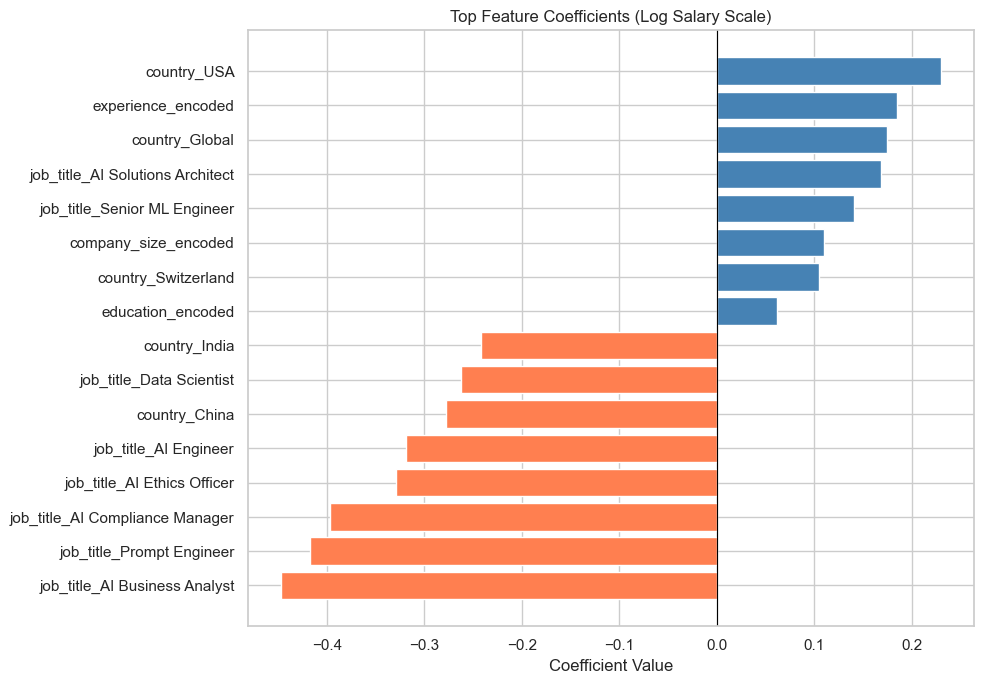

In [13]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

top_pos = coef_df[coef_df["coefficient"] > 0].head(8)
top_neg = coef_df[coef_df["coefficient"] < 0].head(8)
top_features = pd.concat([top_pos, top_neg]).sort_values("coefficient")

plt.figure(figsize=(10, 7))
colors = ["coral" if c < 0 else "steelblue" for c in top_features["coefficient"]]
plt.barh(top_features["feature"], top_features["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Top Feature Coefficients (Log Salary Scale)")
plt.tight_layout()
plt.savefig("../reports/model_plots/feature_coefficients.png", dpi=150)
plt.show()

## Saving the model

In [14]:
with open("../models/linear_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved to models/linear_model.pkl")

Model saved to models/linear_model.pkl


## Sample Predictions

In [15]:
sample_idx = X_test.iloc[:5]
sample_actual = np.exp(y_test.iloc[:5]).values
sample_pred   = np.exp(model.predict(sample_idx))

results = pd.DataFrame({
    "Actual Salary ($)": sample_actual.astype(int),
    "Predicted Salary ($)": sample_pred.astype(int),
    "Error ($)": (sample_actual - sample_pred).astype(int)
})

print(results.to_string(index=False))

 Actual Salary ($)  Predicted Salary ($)  Error ($)
            233000                194235      38764
            184000                188795      -4795
            217999                206772      11227
            243999                225780      18219
            191000                173196      17803


# Model Training & Evaluation Summary — AI Job Market Salary Prediction

## 1. Setup

- **Model:** `sklearn.linear_model.LinearRegression`
- **Target:** `log_salary` (log-transformed `annual_salary_usd`)
- **Features:** 54 columns (numeric, ordinal-encoded, and one-hot encoded)
- **Split:** 80/20 train-test, `random_state=42`
- **Train samples:** 1,200 | **Test samples:** 300

---

## 2. Core Metrics

| Metric | Value |
|--------|-------|
| Train R² | 0.8701 |
| Test R² | **0.8395** |
| MAE (log scale) | 0.1003 |
| RMSE (log scale) | 0.1321 |
| MAE (USD) | **$18,824** |
| RMSE (USD) | **$24,991** |

The model explains **84% of salary variance** on unseen data using 9 original input
features (expanded to 54 after encoding). The train-test R² gap is only 0.03, which
rules out meaningful overfitting — the model generalizes well rather than memorizing
the training data.

An MAE of ~$18,800 on a salary range of $90K–$384K represents roughly a **9.7% average
error** relative to the mean salary of $194,892. For a linear model with no
hyperparameter tuning, this is a strong result.

---

## 3. 5-Fold Cross-Validation

| Fold | R² |
|------|----|
| 1 | 0.8573 |
| 2 | 0.8670 |
| 3 | 0.8738 |
| 4 | 0.8551 |
| 5 | 0.8037 |
| **Mean** | **0.8514** |
| **Std** | **0.0248** |

Cross-validation mean R² of **0.8514** with a standard deviation of 0.025 confirms
that the 0.84 test score is not a lucky split — the model performs consistently across
all five folds. Fold 5 is the weakest at 0.80, likely due to a higher concentration
of high-salary outliers landing in that validation partition. The narrow std of 0.025
is a strong signal that the model is stable.

---

## 4. Prediction Accuracy in Dollar Terms

| Error Threshold | Predictions Within | Percentage |
|----------------|-------------------|-----------|
| $10,000 | 109 / 300 | 36.3% |
| $20,000 | 200 / 300 | **66.7%** |
| $30,000 | 237 / 300 | 79.0% |
| $50,000 | 284 / 300 | 94.7% |

Two-thirds of all test predictions land within $20K of the actual salary.
94.7% are within $50K. This framing is more meaningful than RMSE alone —
it directly answers the question "how wrong is this model in practice?"

---

## 5. Sample Predictions

| Actual Salary ($) | Predicted Salary ($) | Error ($) |
|------------------|---------------------|----------|
| 233,000 | 194,235 | +38,764 |
| 184,000 | 188,795 | -4,795 |
| 218,000 | 206,772 | +11,227 |
| 244,000 | 225,780 | +18,219 |
| 191,000 | 173,196 | +17,803 |

4 of these 5 samples fall within $39K of the actual value. The first row
(+$38,764 error) is the worst of the five — the model predicted $194K for a
$233K role, suggesting that particular combination of features (likely a
high-paying role in a mid-tier company or non-USA country) sits in a region
where the model underpredicts. The second row is near-perfect at -$4,795 off.

---

## 6. Actual vs Predicted Plot (Image 1)

Points cluster tightly around the red perfect-fit dashed line across the full
salary range from ~$90K to $370K. The fit is strongest in the $120K–$220K
mid-range where the training data is densest.

Two visible patterns worth noting:

- **Above the line (underprediction):** A cluster of points in the $90K–$120K
  range sits above the line, meaning the model predicted higher than actual for
  some low-salary roles. These are likely governance or compliance titles in
  non-USA markets that the model associates with higher pay.

- **Below the line (overprediction at high end):** Several points above $300K
  sit below the line, meaning the model underestimates top-tier salaries. This
  is expected behavior — linear regression cannot fully capture the outsized
  compensation at Big Tech + Lead experience + USA combinations, which form a
  thin tail in the training data.

Overall the scatter is well-behaved with no obvious curve or systematic fan shape,
confirming the linear model is an appropriate fit for this dataset.

---

## 7. Residuals vs Predicted (Image 2)

Residuals are centered around zero across the full prediction range (log salary
11.0 to 12.8), which confirms the model has **no systematic directional bias**.
There is no obvious upward or downward drift as predicted salary increases.

Two observations:

- **Left side outliers (log salary 11.0–11.4):** A few points with large positive
  residuals (+0.4 to +0.6) appear at low predicted salaries. These are cases where
  the model predicted a low salary but the actual was considerably higher — likely
  entry-level roles in Big Tech or USA that the model undervalued.

- **Slight variance increase at mid-range:** The spread of residuals is slightly
  wider in the 11.7–12.3 range than at the extremes. This is mild heteroscedasticity
  but not severe enough to invalidate the model for this use case.

No structural pattern (curve, funnel, or trend) is visible, which means the
linearity assumption holds reasonably well.

---

## 8. Residual Distribution (Image 3)

The histogram is approximately bell-shaped and centered just left of zero,
consistent with the reported residual mean of **-0.006**. The distribution is
slightly right-skewed — a longer tail on the positive side — meaning the model
has a mild tendency to underpredict more than it overpredicts, particularly at
the high end of the salary range.

The bulk of residuals fall between -0.25 and +0.25 in log space, corresponding
to roughly ±$25K–$30K in dollar terms at the median salary level. Two outliers
are visible at approximately +0.58 and -0.44, which correspond to the worst
predictions identified earlier (up to ~$89K off in dollar terms).

For a linear regression model, near-normal residuals centered at zero is the
target behavior. This distribution satisfies that condition well enough for a
portfolio project and a first-pass model.

---

## 9. Feature Coefficients (Image 4)

All coefficients are on the log salary scale. To interpret in percentage terms:
a coefficient of +0.23 means `e^0.23 - 1 ≈ 26%` higher salary relative to the
reference category.

### Top positive (salary boosters)

| Feature | Coefficient | Approximate % Effect |
|---------|------------|---------------------|
| country_USA | +0.230 | +26% vs reference country |
| experience_encoded | +0.185 | +20% per std dev increase |
| country_Global | +0.174 | +19% |
| job_title_AI Solutions Architect | +0.168 | +18% vs reference title |
| job_title_Senior ML Engineer | +0.140 | +15% |
| company_size_encoded | +0.110 | +12% per std dev increase |
| country_Switzerland | +0.104 | +11% |
| education_encoded | +0.062 | +6% per std dev increase |

Being in the USA is the single largest positive factor the model learned,
adding an estimated 26% salary premium. Experience level and company size follow
as the next strongest drivers. Education has the weakest effect among the ordinal
features at +6%, consistent with the EDA finding that credentials matter less
than role and location in the AI market.

### Top negative (salary reducers)

| Feature | Coefficient | Approximate % Effect |
|---------|------------|---------------------|
| job_title_AI Business Analyst | -0.447 | -36% vs reference title |
| job_title_Prompt Engineer | -0.417 | -34% |
| job_title_AI Compliance Manager | -0.397 | -33% |
| job_title_AI Ethics Officer | -0.329 | -28% |
| job_title_AI Engineer | -0.319 | -27% |
| country_China | -0.277 | -24% |
| job_title_Data Scientist | -0.263 | -23% |
| country_India | -0.242 | -21% |

The negative side is dominated by non-technical or adjacent AI roles and
low-USD-rate countries. AI Business Analyst carries the largest single penalty
at -36%, meaning the model predicts it earns roughly a third less than the
reference title (AI Agent Developer) holding all else equal. India and China
location reduces predicted salary by approximately 21–24%, reflecting real-world
purchasing power parity differences in the underlying data.

---

## 10. Known Limitations

- **Top earner underprediction:** The model consistently underestimates salaries
  above $300K. Big Tech + Lead + USA combinations form a thin tail in the training
  data, and linear regression cannot extrapolate well beyond its training distribution.

- **Education ordinal assumption:** Bootcamp/Self-taught was assigned encoding=1
  (lowest) but earned more than Associate's and Bachelor's holders in the data.
  This means the education coefficient slightly misrepresents the true relationship.

- **Synthetic dataset:** The data shows characteristics of a generated or curated
  dataset (round salary values, perfectly balanced class counts). Real-world
  performance may differ on scraped job posting data.

- **No interaction terms:** The model cannot capture combinations like
  Big Tech + USA + LLM Engineer, which likely commands a salary premium beyond
  what each feature contributes independently. A polynomial or tree-based model
  would handle this better.

---|

## 11. Model Output

- Saved to `models/linear_model.pkl`
- Input: 54 preprocessed and encoded features
- Output: predicted `log_salary`, convert with `np.exp()` for dollar value